In [2]:
import os
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
import segmentation_models_pytorch as smp
import torchvision.transforms.v2 as T
from fastprogress.fastprogress import master_bar, progress_bar

# Configuración de dispositivo y semillas
pl.seed_everything(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Estadísticas para denormalización (ImageNet)
MEAN = torch.tensor([0.485, 0.456, 0.406])
STD = torch.tensor([0.229, 0.224, 0.225])

def denormalize(tensor):
    m = MEAN.view(3, 1, 1).to(tensor.device)
    s = STD.view(3, 1, 1).to(tensor.device)
    return torch.clamp(tensor * s + m, 0, 1)

# --- MODELO DE INPAINTING (4 CANALES) ---
class LightningModuleInpainting(pl.LightningModule):
    def __init__(self, learning_rate=3e-4):
        super().__init__()
        self.save_hyperparameters()
        # Entrada: RGB (3) + Máscara (1) = 4 canales
        self.model = smp.Unet(encoder_name='resnet50', encoder_weights='imagenet', in_channels=4, classes=3)
        
    def forward(self, x):
        return self.model(x)

# --- DATASET PARA INFERENCIA ---
class FenceInferenceDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transforms=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transforms = transforms
        self.image_files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(".jpg")])

    def __len__(self): return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        base = os.path.splitext(img_name)[0]
        image = Image.open(os.path.join(self.images_dir, img_name)).convert("RGB")
        mask = Image.open(os.path.join(self.labels_dir, base + ".png")).convert("L")

        if self.transforms:
            image, mask = self.transforms(image, mask)
        
        return {"image": image, "mask": (mask > 0.5).float(), "filename": img_name}

Seed set to 42


In [37]:
# Transformaciones de validación
val_transforms = T.Compose([
    T.Resize(512, antialias=True),
   # T.CenterCrop(224),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=MEAN.tolist(), std=STD.tolist()),
])

# INSTANCIACIÓN DEL DATASET (Esto resuelve tu error de "not found")
val_dataset = FenceInferenceDataset(
    images_dir="dataset/Test Set/Test_Images",
    labels_dir="dataset/Test Set/Test_Labels",
    transforms=val_transforms
)

def get_patch_origins(h, w, ps, overlap):
    """Calcula las coordenadas de inicio de cada parche con solapamiento."""
    stride = ps - overlap
    nx = int(np.ceil((h - ps) / stride)) + 1
    ny = int(np.ceil((w - ps) / stride)) + 1
    x_coords = np.linspace(0, h - ps, nx).astype(int)
    y_coords = np.linspace(0, w - ps, ny).astype(int)
    grid_x, grid_y = np.meshgrid(x_coords, y_coords)
    return np.stack([grid_x.ravel(), grid_y.ravel()], axis=-1)

In [ ]:
import cv2
import numpy as np
import torch

def dilate_mask_with_ellipse(mask, ksize=5):
    """
    Realiza una dilatación morfológica usando una elipse.
    
    Args:
        mask (torch.Tensor): Tensor de la máscara [1, H, W] o [C, H, W].
        ksize (int): Tamaño del kernel (debe ser un número impar, ej: 5, 7, 9).
    """
    # 1. Convertir a numpy y asegurar formato 2D [H, W]
    mask_np = mask[0].cpu().numpy()
    
    # 2. Crear el elemento estructurante de ELIPSE
    # cv2.MORPH_ELLIPSE genera una forma elíptica dentro del rectángulo de tamaño ksize
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    
    # 3. Aplicar la dilatación
    dilated_np = cv2.dilate(mask_np, kernel, iterations=1)
    
    # 4. Convertir de vuelta a Tensor y mantener las dimensiones originales [1, H, W]
    return torch.from_numpy(dilated_np).unsqueeze(0)

# Ejemplo de uso dentro de tu bucle de inferencia:
# p_mask_bin = dilate_mask_with_ellipse(p_mask, ksize=7)

Procesando imagen 512x908 con máscara dilatada...


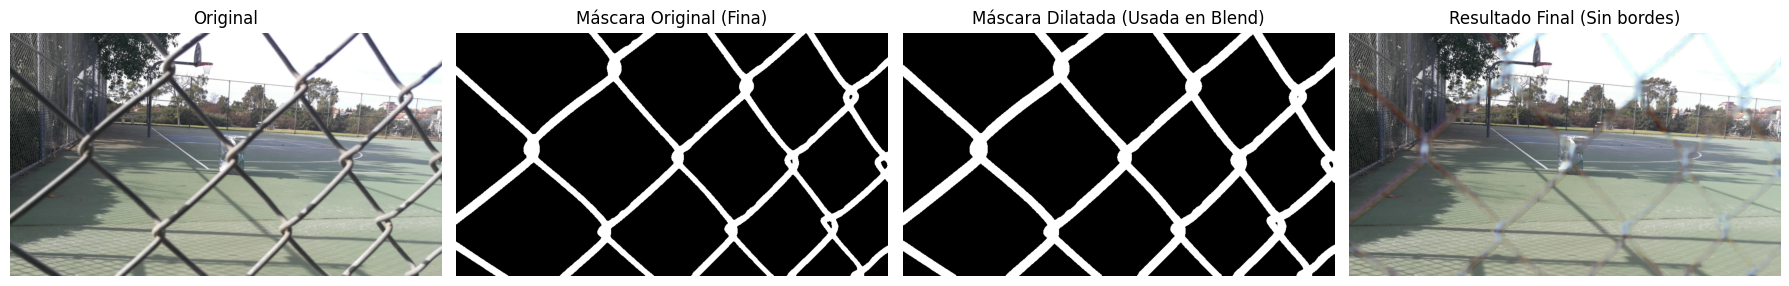

In [40]:
# --- PARÁMETROS ---
PATCH_SIZE = 224
OVERLAP = 32
CKPT_PATH = "checkpoints/augmentation_mask_mix.ckpt" 
DILATION_KERNEL_SIZE = 5 # Aumentar un poco para asegurar que cubrimos bordes metálicos

# 1. Cargar modelo
model_inp = LightningModuleInpainting.load_from_checkpoint(CKPT_PATH).to(DEVICE).eval()

# 2. Seleccionar imagen y máscara
idx = np.random.randint(len(val_dataset))
sample = val_dataset[12]

full_img = sample['image'][:3] # [3, H, W]
full_mask_original = sample['mask'][:1] # [1, H, W] (Fina)
h, w = full_img.shape[1:]

# ---------------------------------------------------------
# PASO CRÍTICO: DILATACIÓN GLOBAL
# Creamos la máscara "gorda" que usaremos para TODO (inferencia y pegado)
# ---------------------------------------------------------
# 1. Convertir a numpy para dilatar
mask_np = full_mask_original[0].numpy()
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (DILATION_KERNEL_SIZE, DILATION_KERNEL_SIZE))
mask_dilated_np = cv2.dilate(mask_np, kernel, iterations=1)

# 2. Convertir de nuevo a Tensor [1, H, W] y binarizar
full_mask_dilated = torch.from_numpy(mask_dilated_np).unsqueeze(0).float()
full_mask_dilated = (full_mask_dilated > 0.5).float()
# ---------------------------------------------------------

# 3. Preparar acumuladores
coords = get_patch_origins(h, w, PATCH_SIZE, OVERLAP)
y_reconstructed = torch.zeros((3, h, w))
weights_map = torch.zeros((1, h, w))

# 4. Bucle de Inferencia por Parches
print(f"Procesando imagen {h}x{w} con máscara dilatada...")
for (cx, cy) in progress_bar(coords):
    # Extraer parches de la imagen y de la MÁSCARA DILATADA
    p_img = full_img[:, cx:cx+PATCH_SIZE, cy:cy+PATCH_SIZE]
    p_mask = full_mask_dilated[:, cx:cx+PATCH_SIZE, cy:cy+PATCH_SIZE] # Usamos la dilatada aquí
    
    # Preparar entrada: Imagen con agujero negro + Máscara Dilatada
    p_masked_rgb = p_img * (1 - p_mask)
    
    # Concatenar [3] + [1] -> [4]
    x_input = torch.cat([p_masked_rgb, p_mask], dim=0).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        p_pred = model_inp(x_input).squeeze(0).cpu() 
    
    y_reconstructed[:, cx:cx+PATCH_SIZE, cy:cy+PATCH_SIZE] += p_pred
    weights_map[:, cx:cx+PATCH_SIZE, cy:cy+PATCH_SIZE] += 1

# 5. Promediado
y_reconstructed /= (weights_map + 1e-8)

# 6. BLENDING FINAL CORREGIDO
# Aquí estaba el error antes. Ahora usamos 'full_mask_dilated' también aquí.
# Esto asegura que el "parche" nuevo cubra totalmente la valla y sus bordes sucios.
final_res = full_img * (1 - full_mask_dilated) + y_reconstructed * full_mask_dilated

# --- VISUALIZACIÓN ---
plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
plt.imshow(denormalize(full_img).permute(1, 2, 0).numpy())
plt.title("Original")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(full_mask_original[0], cmap='gray')
plt.title("Máscara Original (Fina)")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(full_mask_dilated[0], cmap='gray')
plt.title(f"Máscara Dilatada (Usada en Blend)")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(denormalize(final_res).permute(1, 2, 0).numpy())
plt.title("Resultado Final (Sin bordes)")
plt.axis('off')

plt.tight_layout()
plt.show()

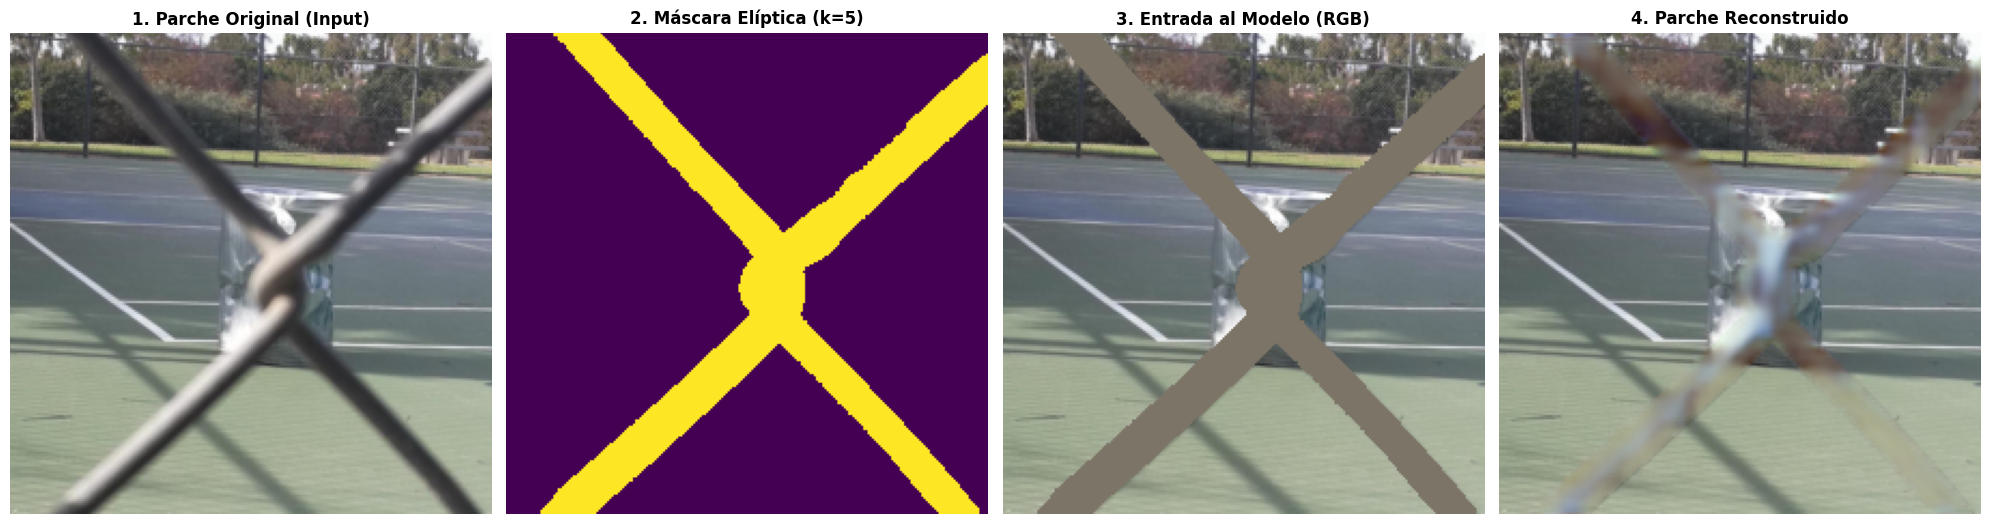

In [39]:
import matplotlib.pyplot as plt

# 1. Seleccionar una imagen aleatoria y extraer un parche central
idx = np.random.randint(len(val_dataset))
sample = val_dataset[12]

full_img = sample['image'] # [3, H, W]
full_mask = sample['mask']  # [1, H, W]
h, w = full_img.shape[1:]

# Coordenadas para un parche central
cx, cy = h // 2 - PATCH_SIZE // 2, w // 2 - PATCH_SIZE // 2
p_img = full_img[:, cx:cx+PATCH_SIZE, cy:cy+PATCH_SIZE]
p_mask = full_mask[:, cx:cx+PATCH_SIZE, cy:cy+PATCH_SIZE]

# 2. Aplicar Dilatación Elíptica (Kernel de 5 o 7 es ideal para parches de 224)
ksize = 5
p_mask_dilated = dilate_mask_with_ellipse(p_mask, ksize=ksize)

# 3. Preparar entrada de 4 canales
p_masked_rgb = p_img * (1 - p_mask_dilated)
x_input = torch.cat([p_masked_rgb, p_mask_dilated], dim=0).unsqueeze(0).to(DEVICE)

# 4. Inferencia del modelo
model_inp.eval()
with torch.no_grad():
    p_pred_t = model_inp(x_input).squeeze(0).cpu()

# 5. Blending del parche (Resultado final local)
p_final = p_img * (1 - p_mask_dilated) + p_pred_t * p_mask_dilated

# --- VISUALIZACIÓN DETALLADA DEL PARCHE ---
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

# Imagen Original del parche
axes[0].imshow(denormalize(p_img).permute(1, 2, 0).numpy())
axes[0].set_title("1. Parche Original (Input)", fontweight='bold')

# Máscara Dilatada
axes[1].imshow(p_mask_dilated[0])
axes[1].set_title(f"2. Máscara Elíptica (k={ksize})", fontweight='bold')

# Entrada al modelo (Imagen con huecos negros)
axes[2].imshow(denormalize(p_masked_rgb).permute(1, 2, 0).numpy())
axes[2].set_title("3. Entrada al Modelo (RGB)", fontweight='bold')

# Resultado de la Inferencia
axes[3].imshow(denormalize(p_final).permute(1, 2, 0).numpy())
axes[3].set_title("4. Parche Reconstruido", fontweight='bold')

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

Visualizando 15 parches de la imagen: 2017_Test_00016.jpg


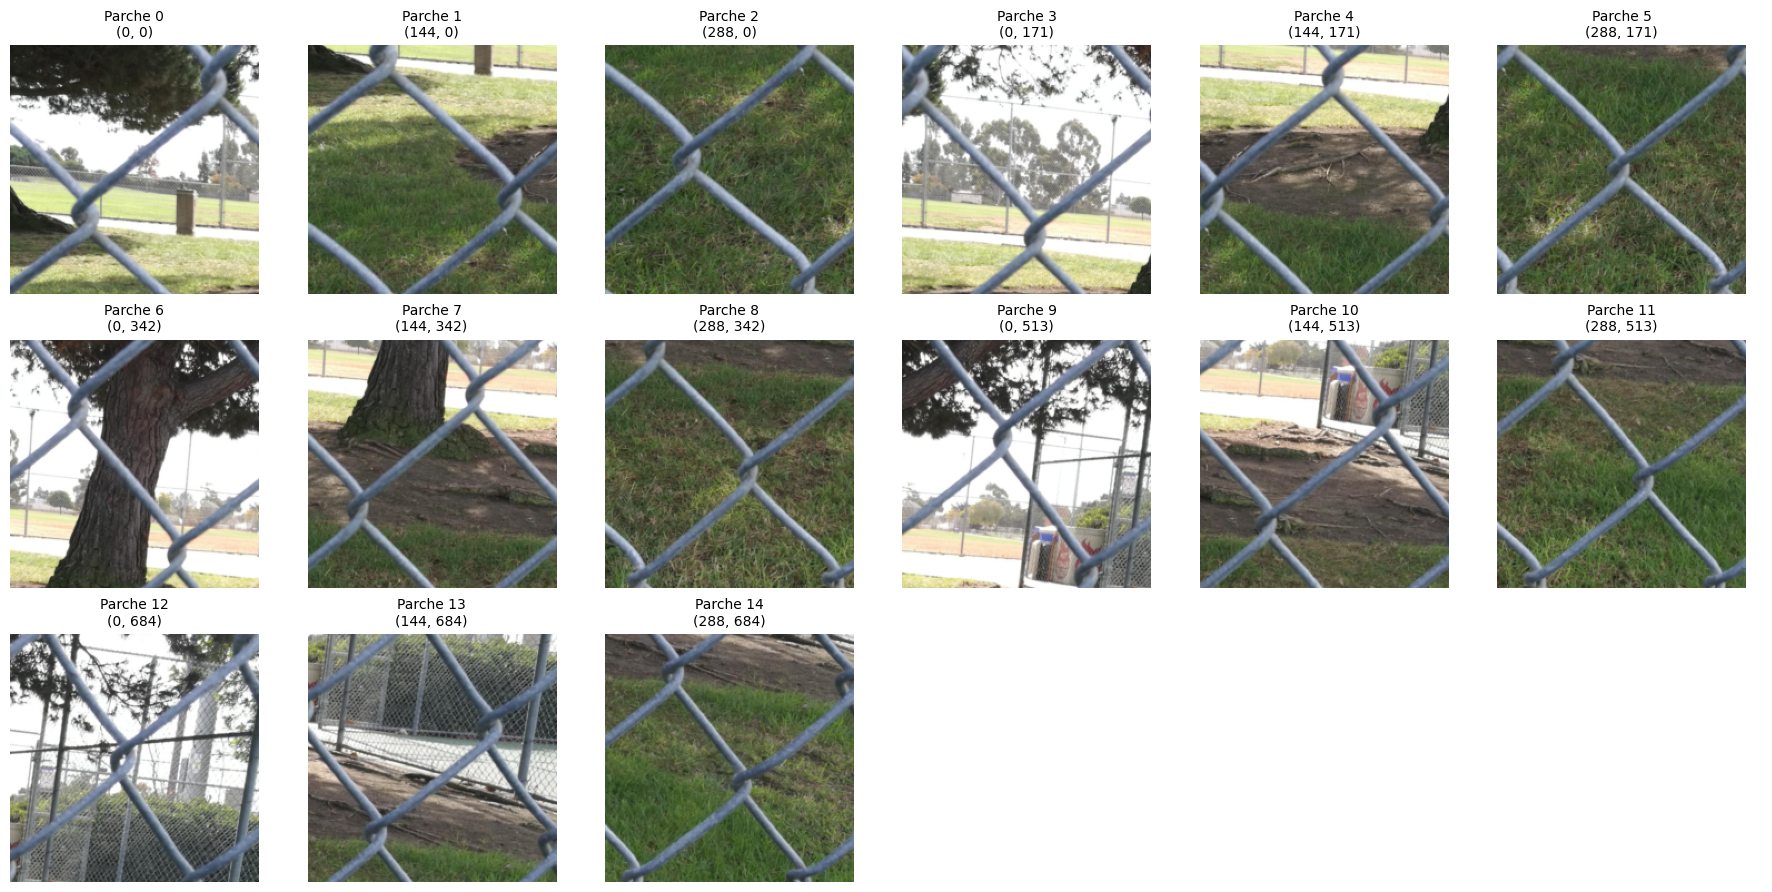

In [38]:
import math

# 1. Seleccionar imagen y calcular coordenadas
idx = np.random.randint(len(val_dataset))
sample = val_dataset[15]
full_img = sample['image']
h, w = full_img.shape[1:]

coords = get_patch_origins(h, w, PATCH_SIZE, OVERLAP)
num_patches = len(coords)

# 2. Configurar la rejilla de visualización
cols = 6  # Número de parches por fila
rows = math.ceil(num_patches / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

print(f"Visualizando {num_patches} parches de la imagen: {sample['filename']}")

# 3. Iterar sobre cada parche y dibujarlo
for i, (cx, cy) in enumerate(coords):
    # Extraer parche
    patch = full_img[:, cx:cx+PATCH_SIZE, cy:cy+PATCH_SIZE]
    
    # Denormalizar para ver colores reales
    patch_img = denormalize(patch).permute(1, 2, 0).numpy()
    
    axes[i].imshow(patch_img)
    axes[i].set_title(f"Parche {i}\n({cx}, {cy})", fontsize=10)
    axes[i].axis('off')

# Ocultar ejes vacíos si los hay
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

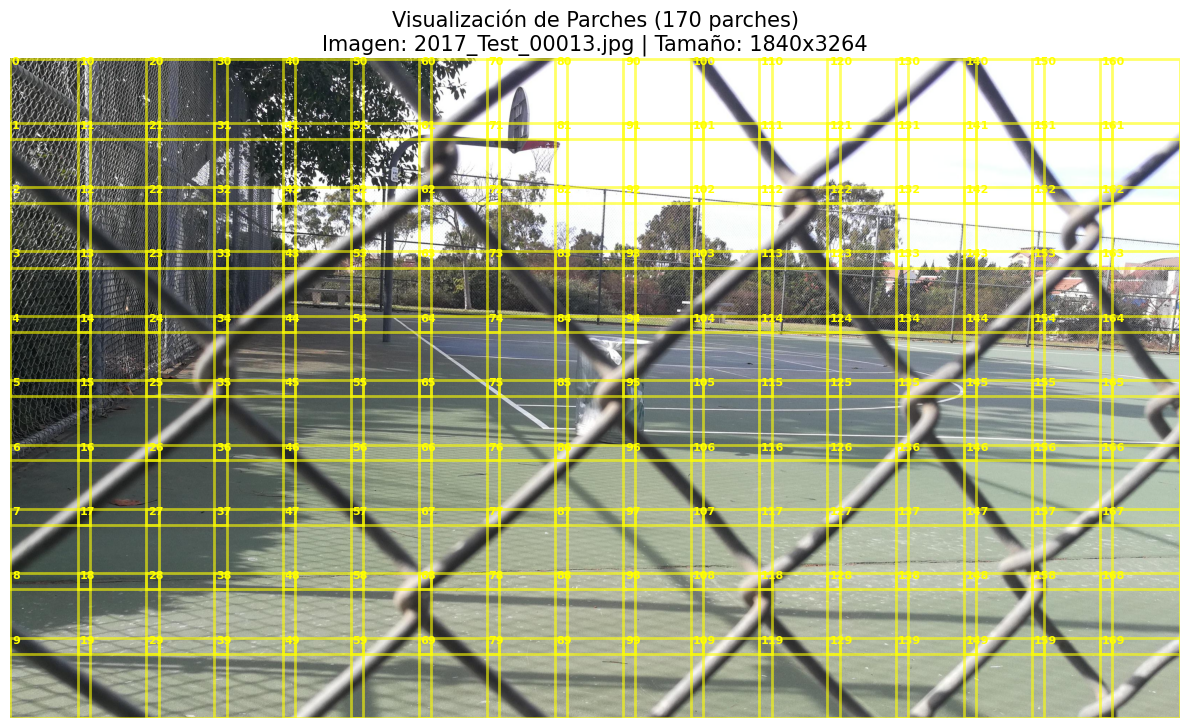

In [35]:
import matplotlib.patches as patches

# 1. Seleccionar una imagen aleatoria
idx = np.random.randint(len(val_dataset))
sample = val_dataset[12]

# Imagen para mostrar (denormalizada)
img_to_show = denormalize(sample['image']).permute(1, 2, 0).numpy()
h, w, _ = img_to_show.shape

# 2. Obtener las coordenadas de los parches
coords = get_patch_origins(h, w, PATCH_SIZE, OVERLAP)

# 3. Crear la visualización
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
ax.imshow(img_to_show)

# Dibujar cada parche como un rectángulo
for i, (cx, cy) in enumerate(coords):
    # En matplotlib, el origen (0,0) es esquina superior izquierda
    # cx es fila (y), cy es columna (x)
    rect = patches.Rectangle(
        (cy, cx),           # (x, y) del origen
        PATCH_SIZE,         # Ancho
        PATCH_SIZE,         # Alto
        linewidth=2, 
        edgecolor='yellow', # Color llamativo
        facecolor='none', 
        alpha=0.6           # Transparencia para ver el solapamiento
    )
    ax.add_patch(rect)
    # Opcional: poner el número del parche
    ax.text(cy+5, cx+15, str(i), color='yellow', fontsize=8, fontweight='bold')

ax.set_title(f"Visualización de Parches ({len(coords)} parches)\nImagen: {sample['filename']} | Tamaño: {h}x{w}", fontsize=15)
ax.axis('off')

plt.tight_layout()

plt.show()